In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

In [4]:
file_path = r"D:\Thesis_Speed_Model\data\Raw\Data Final for Modeling with R1500.xlsx"
df = pd.read_excel(file_path)

In [5]:
df.head()

,SN,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Left Shoulder Width,Left Shoulder Type,Right Shoulder Width,Right Shoulder Type
0,1,57.0,1.27,1500,5.5,0.9,Gravel,0.9,Gravel
1,2,33.0,2.92,46,5.5,0.9,Gravel,0.9,Gravel
2,3,43.0,7.97,1500,5.5,0.9,Gravel,0.9,Gravel
3,4,48.0,2.07,1500,5.5,0.9,Gravel,0.9,Gravel
4,5,36.0,1.21,16,5.5,0.9,Gravel,0.9,Gravel


In [6]:
df.describe()

,SN,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Left Shoulder Width,Right Shoulder Width
count,140.0000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000
mean,70.5000,46.831786,3.872104,567.314286,6.257550,0.512214,0.521143
std,40.5586,10.353012,2.573637,668.940449,0.936458,0.401510,0.394580
min,1.0000,24.000000,0.100000,15.000000,4.700000,0.000000,0.000000
25%,35.7500,40.812500,1.387500,50.000000,5.500000,0.000000,0.000000
50%,70.5000,46.000000,3.765000,120.000000,7.000000,0.500000,0.500000
75%,105.2500,55.000000,5.985000,1500.000000,7.000000,0.900000,0.907500
max,140.0000,74.000000,10.000000,1500.000000,8.000000,1.130000,1.180000


In [7]:
num_cols = [
    "V85 Speed",
    "Gradient",
    "Carriageway Width",
    "Left Shoulder Width",
    "Right Shoulder Width",
    "Radius of Curve"
]

In [8]:
corr_matrix = df[num_cols].corr()
corr_matrix

,V85 Speed,Gradient,Carriageway Width,Left Shoulder Width,Right Shoulder Width,Radius of Curve
V85 Speed,1.000000,-0.014513,0.081495,0.025410,-0.039360,0.489553
Gradient,-0.014513,1.000000,-0.177301,-0.167458,-0.176552,-0.152652
Carriageway Width,0.081495,-0.177301,1.000000,0.032165,-0.207924,0.039981
Left Shoulder Width,0.025410,-0.167458,0.032165,1.000000,0.333377,0.142865
Right Shoulder Width,-0.039360,-0.176552,-0.207924,0.333377,1.000000,0.011811
Radius of Curve,0.489553,-0.152652,0.039981,0.142865,0.011811,1.000000


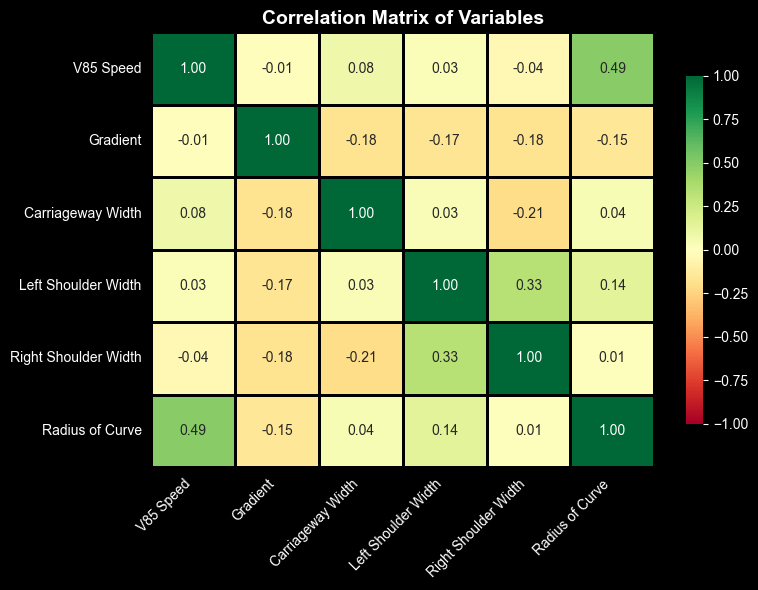

In [11]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="RdYlGn",        # your preferred colors
    vmin=-1, vmax=1,
    center=0,
    fmt=".2f",
    linewidths=0.8,
    linecolor="black",    # darker grid lines
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix of Variables", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [10]:
# Clean categorical text first (avoid space issues)
df["Left Shoulder Type"] = df["Left Shoulder Type"].str.strip()
df["Right Shoulder Type"] = df["Right Shoulder Type"].str.strip()

# Encode as numeric (no bool issue)
df_encoded = pd.get_dummies(
    df,
    columns=["Left Shoulder Type", "Right Shoulder Type"],
    drop_first=True,
    dtype=int
)

In [9]:
df_encoded.head()

,SN,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Left Shoulder Width,Right Shoulder Width,Left Shoulder Type_Gravel,Left Shoulder Type_Paved,Right Shoulder Type_Gravel,Right Shoulder Type_Paved
0,1,57.0,1.27,1500,5.5,0.9,0.9,1,0,1,0
1,2,33.0,2.92,46,5.5,0.9,0.9,1,0,1,0
2,3,43.0,7.97,1500,5.5,0.9,0.9,1,0,1,0
3,4,48.0,2.07,1500,5.5,0.9,0.9,1,0,1,0
4,5,36.0,1.21,16,5.5,0.9,0.9,1,0,1,0


In [10]:
df_encoded.columns

Index(['SN', 'V85 Speed', 'Gradient', 'Radius of Curve', 'Carriageway Width',
       'Left Shoulder Width', 'Right Shoulder Width',
       'Left Shoulder Type_Gravel', 'Left Shoulder Type_Paved',
       'Right Shoulder Type_Gravel', 'Right Shoulder Type_Paved'],
      dtype='str')

In [11]:
X_vif = df_encoded[
    [
        "Gradient",
        "Radius of Curve",
        "Carriageway Width",
        "Left Shoulder Width",
        "Right Shoulder Width",
        "Left Shoulder Type_Gravel",
        "Left Shoulder Type_Paved",
        "Right Shoulder Type_Gravel",
        "Right Shoulder Type_Paved"
    ]
]

In [12]:
X_vif = X_vif.astype(float)

In [13]:
import statsmodels.api as sm
X_vif_const = sm.add_constant(X_vif)

In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif_const.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif_const.values, i)
    for i in range(X_vif_const.shape[1])
]

In [15]:
vif_data.sort_values(by="VIF", ascending=False)

,Feature,VIF
0,const,94.546368
6,Left Shoulder Type_Gravel,6.301732
9,Right Shoulder Type_Paved,5.971506
7,Left Shoulder Type_Paved,5.791759
8,Right Shoulder Type_Gravel,5.244162
4,Left Shoulder Width,5.131911
5,Right Shoulder Width,4.610753
3,Carriageway Width,1.326701
1,Gradient,1.196435
2,Radius of Curve,1.071587


In [16]:
X = df_encoded[
    [
        "Gradient",
        "Radius of Curve",
        "Carriageway Width",
        "Left Shoulder Width",
        "Right Shoulder Width",
        "Left Shoulder Type_Gravel",
        "Left Shoulder Type_Paved",
        "Right Shoulder Type_Gravel",
        "Right Shoulder Type_Paved"
    ]
]

y = df_encoded["V85 Speed"]

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [126]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_validate, KFold
import numpy as np

mlr = LinearRegression()

cv = KFold(n_splits=10, shuffle=True, random_state=42)

scoring = {
    'r2': 'r2',
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error'
}

cv_results = cross_validate(
    mlr,
    X,
    y,
    cv=cv,
    scoring=scoring
)

print("Mean CV R2:", np.mean(cv_results['test_r2']))
print("Mean CV RMSE:", -np.mean(cv_results['test_rmse']))
print("Mean CV MAE:", -np.mean(cv_results['test_mae']))

Mean CV R2: -0.05480961466638653
Mean CV RMSE: 9.615270924730282
Mean CV MAE: 7.750963852929287


In [127]:
mlr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [128]:
y_pred = mlr.predict(X_test)

In [129]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# MLR predictions already exist as y_pred
test_r2 = r2_score(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_mae = mean_absolute_error(y_test, y_pred)

print(test_r2, test_rmse, test_mae)

0.019260584675230952 7.883552972227101 6.298260914507943


In [130]:
print(X_train.dtypes)
print(y_train.dtypes)

Gradient                      float64
Radius of Curve                 int64
Carriageway Width             float64
Left Shoulder Width           float64
Right Shoulder Width          float64
Left Shoulder Type_Gravel       int64
Left Shoulder Type_Paved        int64
Right Shoulder Type_Gravel      int64
Right Shoulder Type_Paved       int64
dtype: object
float64


In [131]:
import statsmodels.api as sm

# copy training data
X_train_sm = X_train.copy()

# convert everything to float (avoids dtype error)
X_train_sm = X_train_sm.astype(float)

# add constant
X_train_sm = sm.add_constant(X_train_sm)

# ensure y is float
y_train_sm = y_train.astype(float)

# fit model
model = sm.OLS(y_train_sm, X_train_sm).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              V85 Speed   R-squared:                       0.299
Model:                            OLS   Adj. R-squared:                  0.237
Method:                 Least Squares   F-statistic:                     4.834
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           2.20e-05
Time:                        11:23:09   Log-Likelihood:                -405.79
No. Observations:                 112   AIC:                             831.6
Df Residuals:                     102   BIC:                             858.8
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

In [132]:
coeff_df = pd.DataFrame({
    "Variable": model.params.index,
    "Coefficient": model.params.values
})

coeff_df

,Variable,Coefficient
0,const,44.431303
1,Gradient,0.164754
2,Radius of Curve,0.009166
3,Carriageway Width,-0.159832
4,Left Shoulder Width,0.348144
5,Right Shoulder Width,1.303042
6,Left Shoulder Type_Gravel,-0.949609
7,Left Shoulder Type_Paved,-1.267968
8,Right Shoulder Type_Gravel,-4.696717
9,Right Shoulder Type_Paved,-1.036916


In [133]:
results_table = pd.DataFrame({
    "Variable": model.params.index,
    "Coefficient": model.params.values,
    "Std Error": model.bse.values,
    "t-Statistic": model.tvalues.values,
    "p-Value": model.pvalues.values,
    "CI Lower": model.conf_int()[0].values,
    "CI Upper": model.conf_int()[1].values
})

results_table = results_table.round(3)
results_table

,Variable,Coefficient,Std Error,t-Statistic,p-Value,CI Lower,CI Upper
0,const,44.431,8.820,5.037,0.000,26.936,61.927
1,Gradient,0.165,0.373,0.441,0.660,-0.576,0.905
2,Radius of Curve,0.009,0.001,6.414,0.000,0.006,0.012
3,Carriageway Width,-0.160,1.127,-0.142,0.888,-2.395,2.076
4,Left Shoulder Width,0.348,5.059,0.069,0.945,-9.687,10.383
5,Right Shoulder Width,1.303,4.758,0.274,0.785,-8.134,10.740
6,Left Shoulder Type_Gravel,-0.950,4.599,-0.206,0.837,-10.071,8.172
7,Left Shoulder Type_Paved,-1.268,4.704,-0.270,0.788,-10.598,8.062
8,Right Shoulder Type_Gravel,-4.697,4.234,-1.109,0.270,-13.095,3.702
9,Right Shoulder Type_Paved,-1.037,4.497,-0.231,0.818,-9.956,7.882


In [134]:
results_table["Significant"] = results_table["p-Value"] < 0.05
results_table

,Variable,Coefficient,Std Error,t-Statistic,p-Value,CI Lower,CI Upper,Significant
0,const,44.431,8.820,5.037,0.000,26.936,61.927,True
1,Gradient,0.165,0.373,0.441,0.660,-0.576,0.905,False
2,Radius of Curve,0.009,0.001,6.414,0.000,0.006,0.012,True
3,Carriageway Width,-0.160,1.127,-0.142,0.888,-2.395,2.076,False
4,Left Shoulder Width,0.348,5.059,0.069,0.945,-9.687,10.383,False
5,Right Shoulder Width,1.303,4.758,0.274,0.785,-8.134,10.740,False
6,Left Shoulder Type_Gravel,-0.950,4.599,-0.206,0.837,-10.071,8.172,False
7,Left Shoulder Type_Paved,-1.268,4.704,-0.270,0.788,-10.598,8.062,False
8,Right Shoulder Type_Gravel,-4.697,4.234,-1.109,0.270,-13.095,3.702,False
9,Right Shoulder Type_Paved,-1.037,4.497,-0.231,0.818,-9.956,7.882,False


In [135]:
results_summary = pd.DataFrame({
    "Metric": ["R2", "RMSE", "MAE"],
    "Cross-Validation": [
        np.mean(cv_results['test_r2']),
        -np.mean(cv_results['test_rmse']),
        -np.mean(cv_results['test_mae'])
    ],
    "Test Set": [
        r2_score(y_test, y_pred),
        np.sqrt(mean_squared_error(y_test, y_pred)),
        mean_absolute_error(y_test, y_pred)
    ]
})

results_summary.round(3)

,Metric,Cross-Validation,Test Set
0,R2,-0.055,0.019
1,RMSE,9.615,7.884
2,MAE,7.751,6.298


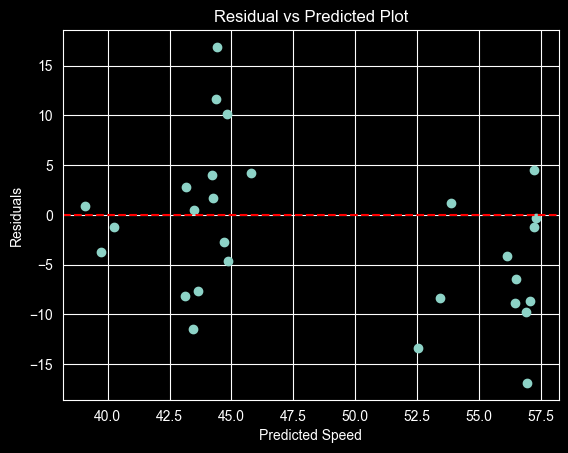

In [136]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Speed")
plt.ylabel("Residuals")
plt.title("Residual vs Predicted Plot")
plt.show()

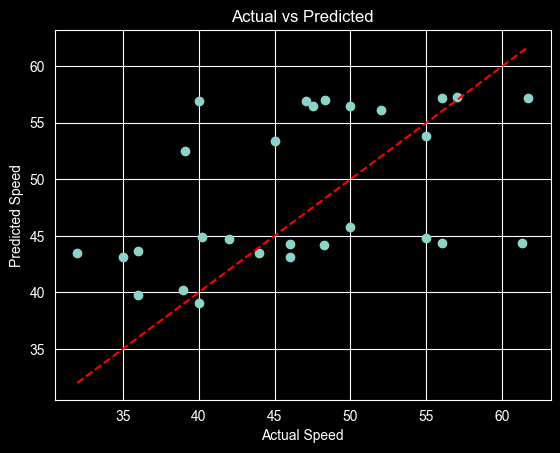

In [137]:
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Speed")
plt.ylabel("Predicted Speed")
plt.title("Actual vs Predicted")
plt.show()

In [138]:
X = df_encoded[
    [
        "Gradient",
        "Radius of Curve",
        "Carriageway Width",
        "Left Shoulder Width",
        "Right Shoulder Width",
        "Left Shoulder Type_Gravel",
        "Left Shoulder Type_Paved",
        "Right Shoulder Type_Gravel",
        "Right Shoulder Type_Paved"
    ]
]

y = df_encoded["V85 Speed"]

In [139]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [140]:
from sklearn.ensemble import RandomForestRegressor

rf_base = RandomForestRegressor(random_state=42)

In [141]:
from sklearn.model_selection import KFold, cross_validate
import numpy as np

cv = KFold(n_splits=10, shuffle=True, random_state=42)

scoring = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error"
}

cv_results_rf = cross_validate(
    rf_base,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Base RF Mean CV R2:", np.mean(cv_results_rf["test_r2"]))
print("Base RF Mean CV RMSE:", -np.mean(cv_results_rf["test_rmse"]))
print("Base RF Mean CV MAE:", -np.mean(cv_results_rf["test_mae"]))

Base RF Mean CV R2: 0.18818906375907465
Base RF Mean CV RMSE: 8.282583463647462
Base RF Mean CV MAE: 6.407642857142859


In [142]:
rf_base.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [143]:
y_pred_rf = rf_base.predict(X_test)

In [144]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

rf_test_r2 = r2_score(y_test, y_pred_rf)
rf_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_test_mae = mean_absolute_error(y_test, y_pred_rf)

print("Base RF Test R2:", rf_test_r2)
print("Base RF Test RMSE:", rf_test_rmse)
print("Base RF Test MAE:", rf_test_mae)

Base RF Test R2: 0.08058207882238488
Base RF Test RMSE: 7.6331124017336505
Base RF Test MAE: 6.179232142857147


In [165]:
rf_base_results = pd.DataFrame({
    "Metric": ["R2", "RMSE", "MAE"],
    "CV Mean": [
        np.mean(cv_results_rf["test_r2"]),
        -np.mean(cv_results_rf["test_rmse"]),
        -np.mean(cv_results_rf["test_mae"])
    ],
    "Test Set": [
        rf_test_r2,
        rf_test_rmse,
        rf_test_mae
    ]
})

rf_base_results.round(3)

,Metric,CV Mean,Test Set
0,R2,0.188,0.081
1,RMSE,8.283,7.633
2,MAE,6.408,6.179


In [146]:
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_base.feature_importances_
}).sort_values(by="Importance", ascending=False)

rf_importance

,Feature,Importance
1,Radius of Curve,0.550381
0,Gradient,0.220190
4,Right Shoulder Width,0.062511
3,Left Shoulder Width,0.055577
2,Carriageway Width,0.049160
5,Left Shoulder Type_Gravel,0.019010
7,Right Shoulder Type_Gravel,0.016720
6,Left Shoulder Type_Paved,0.013829
8,Right Shoulder Type_Paved,0.012622


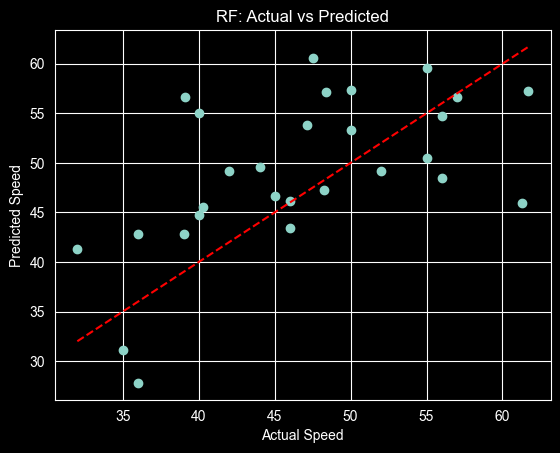

In [147]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_rf)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Speed")
plt.ylabel("Predicted Speed")
plt.title("RF: Actual vs Predicted")
plt.show()

In [166]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", None]
}

In [167]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    scoring="r2",
    cv=cv,
    n_jobs=-1
)

In [168]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', None], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation ti

In [169]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


In [170]:
best_rf = grid_search.best_estimator_

In [171]:
from sklearn.model_selection import cross_validate
import numpy as np

scoring = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error"
}

cv_results_tuned_rf = cross_validate(
    best_rf,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Tuned RF Mean CV R2:", np.mean(cv_results_tuned_rf["test_r2"]))
print("Tuned RF Mean CV RMSE:", -np.mean(cv_results_tuned_rf["test_rmse"]))
print("Tuned RF Mean CV MAE:", -np.mean(cv_results_tuned_rf["test_mae"]))

Tuned RF Mean CV R2: 0.2601376014731044
Tuned RF Mean CV RMSE: 8.01181231955316
Tuned RF Mean CV MAE: 6.340003666480756


In [172]:
best_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

In [173]:
y_pred_tuned_rf = best_rf.predict(X_test)

In [174]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

tuned_rf_test_r2 = r2_score(y_test, y_pred_tuned_rf)
tuned_rf_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned_rf))
tuned_rf_test_mae = mean_absolute_error(y_test, y_pred_tuned_rf)

print("Tuned RF Test R2:", tuned_rf_test_r2)
print("Tuned RF Test RMSE:", tuned_rf_test_rmse)
print("Tuned RF Test MAE:", tuned_rf_test_mae)

Tuned RF Test R2: 0.2637515986502964
Tuned RF Test RMSE: 6.830576469355693
Tuned RF Test MAE: 5.287215186698224


In [175]:
rf_tuned_results = pd.DataFrame({
    "Metric": ["R2", "RMSE", "MAE"],
    "CV Mean": [
        np.mean(cv_results_tuned_rf["test_r2"]),
        -np.mean(cv_results_tuned_rf["test_rmse"]),
        -np.mean(cv_results_tuned_rf["test_mae"])
    ],
    "Test Set": [
        tuned_rf_test_r2,
        tuned_rf_test_rmse,
        tuned_rf_test_mae
    ]
})

rf_tuned_results.round(3)

,Metric,CV Mean,Test Set
0,R2,0.260,0.264
1,RMSE,8.012,6.831
2,MAE,6.340,5.287


In [176]:
rf_tuned_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

rf_tuned_importance

,Feature,Importance
1,Radius of Curve,0.526351
0,Gradient,0.218529
4,Right Shoulder Width,0.069578
3,Left Shoulder Width,0.058884
2,Carriageway Width,0.055102
7,Right Shoulder Type_Gravel,0.023019
5,Left Shoulder Type_Gravel,0.018934
8,Right Shoulder Type_Paved,0.015193
6,Left Shoulder Type_Paved,0.014410


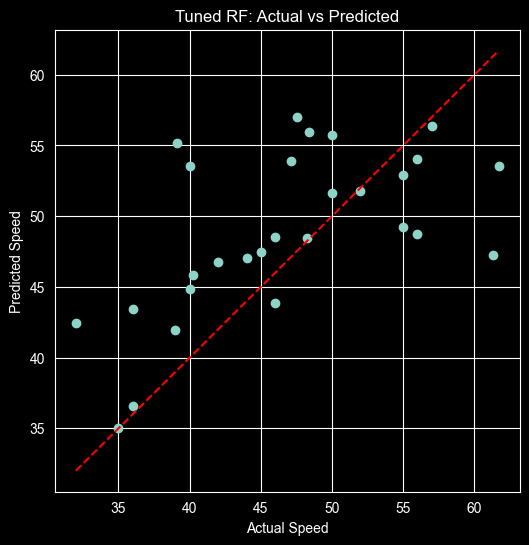

In [177]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_tuned_rf)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("Actual Speed")
plt.ylabel("Predicted Speed")
plt.title("Tuned RF: Actual vs Predicted")

plt.show()

In [178]:
rf_results_table = pd.DataFrame({
    "Metric": ["R2", "RMSE", "MAE"],
    "Base CV": [
        np.mean(cv_results_rf["test_r2"]),
        -np.mean(cv_results_rf["test_rmse"]),
        -np.mean(cv_results_rf["test_mae"])
    ],
    "Base Test": [
        rf_test_r2,
        rf_test_rmse,
        rf_test_mae
    ],
    "Tuned CV": [
        np.mean(cv_results_tuned_rf["test_r2"]),
        -np.mean(cv_results_tuned_rf["test_rmse"]),
        -np.mean(cv_results_tuned_rf["test_mae"])
    ],
    "Tuned Test": [
        tuned_rf_test_r2,
        tuned_rf_test_rmse,
        tuned_rf_test_mae
    ]
})

rf_results_table.round(3)

,Metric,Base CV,Base Test,Tuned CV,Tuned Test
0,R2,0.188,0.081,0.260,0.264
1,RMSE,8.283,7.633,8.012,6.831
2,MAE,6.408,6.179,6.340,5.287


In [54]:
from xgboost import XGBRegressor

xgb_base = XGBRegressor(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    objective="reg:squarederror"
)

In [179]:
from sklearn.model_selection import cross_validate
import numpy as np

scoring = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error"
}

cv_results_xgb = cross_validate(
    xgb_base,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Base XGB Mean CV R2:", np.mean(cv_results_xgb["test_r2"]))
print("Base XGB Mean CV RMSE:", -np.mean(cv_results_xgb["test_rmse"]))
print("Base XGB Mean CV MAE:", -np.mean(cv_results_xgb["test_mae"]))

Base XGB Mean CV R2: 0.03349024507507272
Base XGB Mean CV RMSE: 8.960490124702485
Base XGB Mean CV MAE: 7.017631013052804


In [180]:
xgb_base.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [181]:
y_pred_xgb = xgb_base.predict(X_test)

In [182]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

xgb_test_r2 = r2_score(y_test, y_pred_xgb)
xgb_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
xgb_test_mae = mean_absolute_error(y_test, y_pred_xgb)

print("Base XGB Test R2:", xgb_test_r2)
print("Base XGB Test RMSE:", xgb_test_rmse)
print("Base XGB Test MAE:", xgb_test_mae)

Base XGB Test R2: 0.02168605898831566
Base XGB Test RMSE: 7.873798499292796
Base XGB Test MAE: 5.729824011666436


In [183]:
import pandas as pd

xgb_base_results = pd.DataFrame({
    "Metric": ["R2", "RMSE", "MAE"],
    "CV Mean": [
        np.mean(cv_results_xgb["test_r2"]),
        -np.mean(cv_results_xgb["test_rmse"]),
        -np.mean(cv_results_xgb["test_mae"])
    ],
    "Test Set": [
        xgb_test_r2,
        xgb_test_rmse,
        xgb_test_mae
    ]
})

xgb_base_results.round(3)

,Metric,CV Mean,Test Set
0,R2,0.033,0.022
1,RMSE,8.960,7.874
2,MAE,7.018,5.730


In [184]:
xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_base.feature_importances_
}).sort_values(by="Importance", ascending=False)

xgb_importance

,Feature,Importance
1,Radius of Curve,0.394711
7,Right Shoulder Type_Gravel,0.116746
5,Left Shoulder Type_Gravel,0.110178
4,Right Shoulder Width,0.105496
3,Left Shoulder Width,0.084444
0,Gradient,0.079225
2,Carriageway Width,0.055423
6,Left Shoulder Type_Paved,0.038789
8,Right Shoulder Type_Paved,0.014988


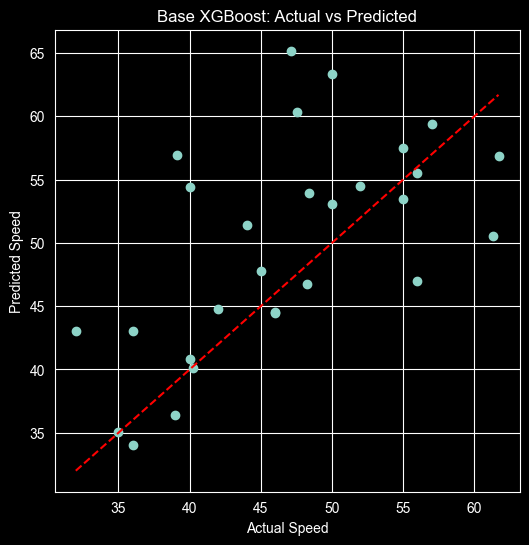

In [185]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_xgb)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("Actual Speed")
plt.ylabel("Predicted Speed")
plt.title("Base XGBoost: Actual vs Predicted")

plt.show()

In [186]:
param_grid_xgb = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 5],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

In [187]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

grid_search_xgb = GridSearchCV(
    estimator=XGBRegressor(
        random_state=42,
        objective="reg:squarederror"
    ),
    param_grid=param_grid_xgb,
    scoring="r2",
    cv=cv,
    n_jobs=-1
)

In [188]:
grid_search_xgb.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 3, ...], 'n_estimators': [50, 100, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the compu

In [189]:
print("Best XGBoost Parameters:")
print(grid_search_xgb.best_params_)

Best XGBoost Parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 200, 'subsample': 1.0}


In [190]:
best_xgb = grid_search_xgb.best_estimator_

In [192]:
from sklearn.model_selection import cross_validate
import numpy as np

scoring = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error"
}

cv_results_tuned_xgb = cross_validate(
    best_xgb,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Tuned XGB Mean CV R2:", np.mean(cv_results_tuned_xgb["test_r2"]))
print("Tuned XGB Mean CV RMSE:", -np.mean(cv_results_tuned_xgb["test_rmse"]))
print("Tuned XGB Mean CV MAE:", -np.mean(cv_results_tuned_xgb["test_mae"]))

Tuned XGB Mean CV R2: 0.2326208863215553
Tuned XGB Mean CV RMSE: 8.263684288917522
Tuned XGB Mean CV MAE: 6.471791419982909


In [193]:
best_xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1.0
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [194]:
y_pred_tuned_xgb = best_xgb.predict(X_test)

In [195]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

tuned_xgb_test_r2 = r2_score(y_test, y_pred_tuned_xgb)
tuned_xgb_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned_xgb))
tuned_xgb_test_mae = mean_absolute_error(y_test, y_pred_tuned_xgb)

print("Tuned XGB Test R2:", tuned_xgb_test_r2)
print("Tuned XGB Test RMSE:", tuned_xgb_test_rmse)
print("Tuned XGB Test MAE:", tuned_xgb_test_mae)

Tuned XGB Test R2: 0.30208082125359215
Tuned XGB Test RMSE: 6.650399605397091
Tuned XGB Test MAE: 5.243025316510883


In [196]:
xgb_tuned_results = pd.DataFrame({
    "Metric": ["R2", "RMSE", "MAE"],
    "CV Mean": [
        np.mean(cv_results_tuned_xgb["test_r2"]),
        -np.mean(cv_results_tuned_xgb["test_rmse"]),
        -np.mean(cv_results_tuned_xgb["test_mae"])
    ],
    "Test Set": [
        tuned_xgb_test_r2,
        tuned_xgb_test_rmse,
        tuned_xgb_test_mae
    ]
})

xgb_tuned_results.round(3)

,Metric,CV Mean,Test Set
0,R2,0.233,0.302
1,RMSE,8.264,6.650
2,MAE,6.472,5.243


In [197]:
xgb_tuned_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

xgb_tuned_importance

,Feature,Importance
1,Radius of Curve,0.491438
5,Left Shoulder Type_Gravel,0.151121
4,Right Shoulder Width,0.133533
0,Gradient,0.093251
7,Right Shoulder Type_Gravel,0.082839
2,Carriageway Width,0.047817
3,Left Shoulder Width,0.000000
6,Left Shoulder Type_Paved,0.000000
8,Right Shoulder Type_Paved,0.000000


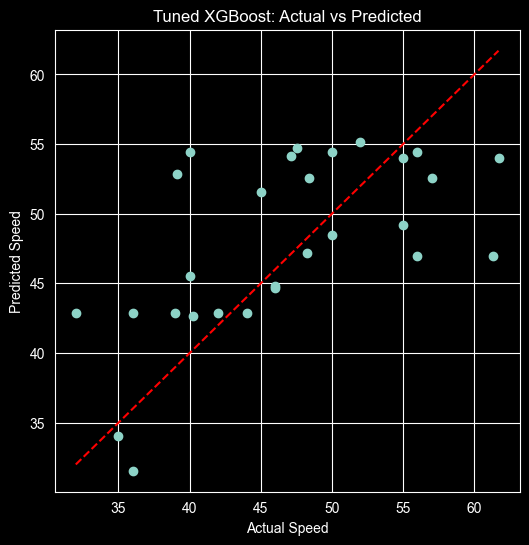

In [198]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_tuned_xgb)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("Actual Speed")
plt.ylabel("Predicted Speed")
plt.title("Tuned XGBoost: Actual vs Predicted")

plt.show()

In [199]:
xgb_results_table = pd.DataFrame({
    "Metric": ["R2", "RMSE", "MAE"],
    "Base CV": [
        np.mean(cv_results_xgb["test_r2"]),
        -np.mean(cv_results_xgb["test_rmse"]),
        -np.mean(cv_results_xgb["test_mae"])
    ],
    "Base Test": [
        xgb_test_r2,
        xgb_test_rmse,
        xgb_test_mae
    ],
    "Tuned CV": [
        np.mean(cv_results_tuned_xgb["test_r2"]),
        -np.mean(cv_results_tuned_xgb["test_rmse"]),
        -np.mean(cv_results_tuned_xgb["test_mae"])
    ],
    "Tuned Test": [
        tuned_xgb_test_r2,
        tuned_xgb_test_rmse,
        tuned_xgb_test_mae
    ]
})

xgb_results_table.round(3)

,Metric,Base CV,Base Test,Tuned CV,Tuned Test
0,R2,0.033,0.022,0.233,0.302
1,RMSE,8.960,7.874,8.264,6.650
2,MAE,7.018,5.730,6.472,5.243


SVR MODEL

In [200]:
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

svr_base = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR())
])

In [201]:
from sklearn.model_selection import cross_validate
import numpy as np

scoring = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error"
}

cv_results_svr = cross_validate(
    svr_base,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Base SVR Mean CV R2:", np.mean(cv_results_svr["test_r2"]))
print("Base SVR Mean CV RMSE:", -np.mean(cv_results_svr["test_rmse"]))
print("Base SVR Mean CV MAE:", -np.mean(cv_results_svr["test_mae"]))

Base SVR Mean CV R2: -0.007469540089062065
Base SVR Mean CV RMSE: 9.73445001485334
Base SVR Mean CV MAE: 7.951250052527756


In [202]:
svr_base.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('svr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0


In [209]:
y_pred_svr = svr_base.predict(X_test)

In [210]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

svr_test_r2 = r2_score(y_test, y_pred_svr)
svr_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_svr))
svr_test_mae = mean_absolute_error(y_test, y_pred_svr)

print("Base SVR Test R2:", svr_test_r2)
print("Base SVR Test RMSE:", svr_test_rmse)
print("Base SVR Test MAE:", svr_test_mae)

Base SVR Test R2: 0.14166073083559272
Base SVR Test RMSE: 7.3752146782670485
Base SVR Test MAE: 6.106826149413976


In [211]:
import pandas as pd

svr_base_results = pd.DataFrame({
    "Metric": ["R2", "RMSE", "MAE"],
    "Base CV": [
        np.mean(cv_results_svr["test_r2"]),
        -np.mean(cv_results_svr["test_rmse"]),
        -np.mean(cv_results_svr["test_mae"])
    ],
    "Base Test": [
        svr_test_r2,
        svr_test_rmse,
        svr_test_mae
    ]
})

svr_base_results.round(3)

,Metric,Base CV,Base Test
0,R2,-0.007,0.142
1,RMSE,9.734,7.375
2,MAE,7.951,6.107


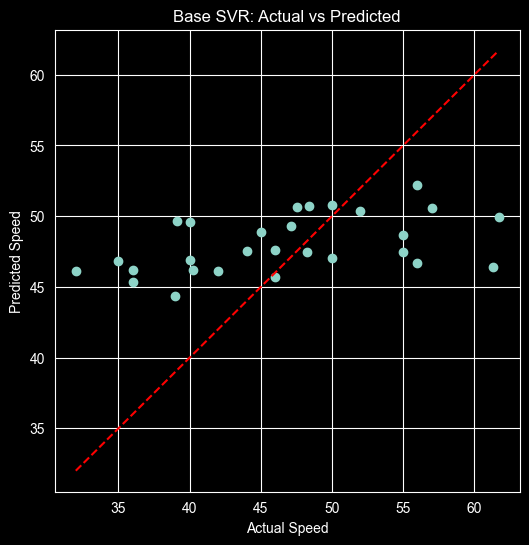

In [212]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_svr)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("Actual Speed")
plt.ylabel("Predicted Speed")
plt.title("Base SVR: Actual vs Predicted")

plt.show()

In [213]:
param_grid_svr = {
    "svr__kernel": ["rbf", "linear"],
    "svr__C": [0.1, 1, 10, 100],
    "svr__epsilon": [0.1, 0.5, 1.0],
    "svr__gamma": ["scale", "auto"]
}

In [214]:
from sklearn.model_selection import GridSearchCV

grid_search_svr = GridSearchCV(
    estimator=svr_base,
    param_grid=param_grid_svr,
    scoring="r2",
    cv=cv,
    n_jobs=-1
)

In [215]:
grid_search_svr.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...svr', SVR())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'svr__C': [0.1, 1, ...], 'svr__epsilon': [0.1, 0.5, ...], 'svr__gamma': ['scale', 'auto'], 'svr__kernel': ['rbf', 'linear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation

In [216]:
print("Best SVR Parameters:")
print(grid_search_svr.best_params_)

Best SVR Parameters:
{'svr__C': 0.1, 'svr__epsilon': 1.0, 'svr__gamma': 'scale', 'svr__kernel': 'linear'}


In [217]:
best_svr = grid_search_svr.best_estimator_

In [218]:
from sklearn.model_selection import cross_validate
import numpy as np

scoring = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error"
}

cv_results_tuned_svr = cross_validate(
    best_svr,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Tuned SVR Mean CV R2:", np.mean(cv_results_tuned_svr["test_r2"]))
print("Tuned SVR Mean CV RMSE:", -np.mean(cv_results_tuned_svr["test_rmse"]))
print("Tuned SVR Mean CV MAE:", -np.mean(cv_results_tuned_svr["test_mae"]))

Tuned SVR Mean CV R2: 0.029533029441472635
Tuned SVR Mean CV RMSE: 9.465067944645169
Tuned SVR Mean CV MAE: 7.626218314688819


In [219]:
best_svr.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('svr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0


In [220]:
y_pred_tuned_svr = best_svr.predict(X_test)

In [221]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

tuned_svr_test_r2 = r2_score(y_test, y_pred_tuned_svr)
tuned_svr_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned_svr))
tuned_svr_test_mae = mean_absolute_error(y_test, y_pred_tuned_svr)

print("Tuned SVR Test R2:", tuned_svr_test_r2)
print("Tuned SVR Test RMSE:", tuned_svr_test_rmse)
print("Tuned SVR Test MAE:", tuned_svr_test_mae)

Tuned SVR Test R2: 0.125833735291224
Tuned SVR Test RMSE: 7.442900214343066
Tuned SVR Test MAE: 6.253615961880114


In [222]:
svr_results_table = pd.DataFrame({
    "Metric": ["R2", "RMSE", "MAE"],
    "Base CV": [
        np.mean(cv_results_svr["test_r2"]),
        -np.mean(cv_results_svr["test_rmse"]),
        -np.mean(cv_results_svr["test_mae"])
    ],
    "Base Test": [
        svr_test_r2,
        svr_test_rmse,
        svr_test_mae
    ],
    "Tuned CV": [
        np.mean(cv_results_tuned_svr["test_r2"]),
        -np.mean(cv_results_tuned_svr["test_rmse"]),
        -np.mean(cv_results_tuned_svr["test_mae"])
    ],
    "Tuned Test": [
        tuned_svr_test_r2,
        tuned_svr_test_rmse,
        tuned_svr_test_mae
    ]
})

svr_results_table.round(3)

,Metric,Base CV,Base Test,Tuned CV,Tuned Test
0,R2,-0.007,0.142,0.030,0.126
1,RMSE,9.734,7.375,9.465,7.443
2,MAE,7.951,6.107,7.626,6.254


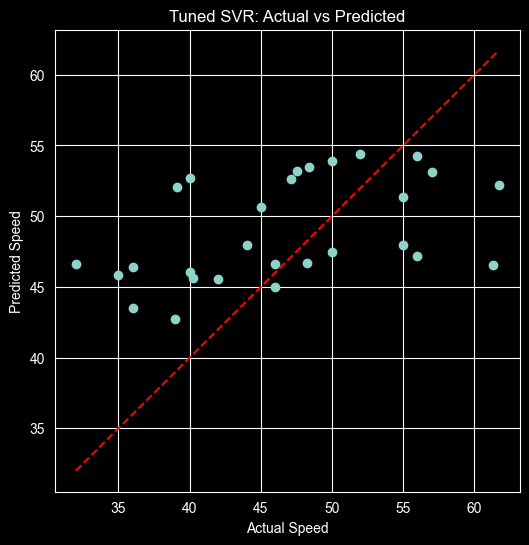

In [223]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_tuned_svr)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("Actual Speed")
plt.ylabel("Predicted Speed")
plt.title("Tuned SVR: Actual vs Predicted")

plt.show()

ANN

In [224]:
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

ann_base = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(50,),
        activation="relu",
        solver="adam",
        max_iter=2000,
        random_state=42
    ))
])

In [225]:
from sklearn.model_selection import cross_validate
import numpy as np

scoring = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error"
}

cv_results_ann = cross_validate(
    ann_base,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Base ANN Mean CV R2:", np.mean(cv_results_ann["test_r2"]))
print("Base ANN Mean CV RMSE:", -np.mean(cv_results_ann["test_rmse"]))
print("Base ANN Mean CV MAE:", -np.mean(cv_results_ann["test_mae"]))

Base ANN Mean CV R2: -0.07812936443002749
Base ANN Mean CV RMSE: 9.851541974491798
Base ANN Mean CV MAE: 8.039803854678677


In [226]:
ann_base.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('mlp', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(50,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_traini

In [227]:
y_pred_ann = ann_base.predict(X_test)

In [228]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

ann_test_r2 = r2_score(y_test, y_pred_ann)
ann_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ann))
ann_test_mae = mean_absolute_error(y_test, y_pred_ann)

print("Base ANN Test R2:", ann_test_r2)
print("Base ANN Test RMSE:", ann_test_rmse)
print("Base ANN Test MAE:", ann_test_mae)

Base ANN Test R2: 0.16904199211829807
Base ANN Test RMSE: 7.2566255573772915
Base ANN Test MAE: 5.942627570394465


In [229]:
import pandas as pd

ann_base_results = pd.DataFrame({
    "Metric": ["R2", "RMSE", "MAE"],
    "Base CV": [
        np.mean(cv_results_ann["test_r2"]),
        -np.mean(cv_results_ann["test_rmse"]),
        -np.mean(cv_results_ann["test_mae"])
    ],
    "Base Test": [
        ann_test_r2,
        ann_test_rmse,
        ann_test_mae
    ]
})

ann_base_results.round(3)

,Metric,Base CV,Base Test
0,R2,-0.078,0.169
1,RMSE,9.852,7.257
2,MAE,8.040,5.943


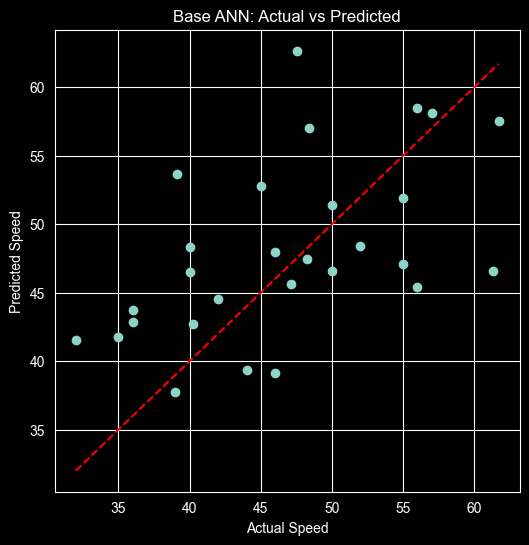

In [230]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_ann)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("Actual Speed")
plt.ylabel("Predicted Speed")
plt.title("Base ANN: Actual vs Predicted")

plt.show()

In [231]:
param_grid_ann = {
    "mlp__hidden_layer_sizes": [(25,), (50,), (100,), (50, 25)],
    "mlp__activation": ["relu", "tanh"],
    "mlp__alpha": [0.0001, 0.001, 0.01],
    "mlp__learning_rate_init": [0.001, 0.01]
}

In [232]:
from sklearn.model_selection import GridSearchCV

grid_search_ann = GridSearchCV(
    estimator=ann_base,
    param_grid=param_grid_ann,
    scoring="r2",
    cv=cv,
    n_jobs=-1
)

In [233]:
grid_search_ann.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'mlp__activation': ['relu', 'tanh'], 'mlp__alpha': [0.0001, 0.001, ...], 'mlp__hidden_layer_sizes': [(25,), (50,), ...], 'mlp__learning_rate_init': [0.001, 0.01]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the 

In [234]:
print("Best ANN Parameters:")
print(grid_search_ann.best_params_)

Best ANN Parameters:
{'mlp__activation': 'tanh', 'mlp__alpha': 0.01, 'mlp__hidden_layer_sizes': (50,), 'mlp__learning_rate_init': 0.001}


In [104]:
best_ann = grid_search_ann.best_estimator_

In [235]:
cv_results_tuned_ann = cross_validate(
    best_ann,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Tuned ANN Mean CV R2:", np.mean(cv_results_tuned_ann["test_r2"]))
print("Tuned ANN Mean CV RMSE:", -np.mean(cv_results_tuned_ann["test_rmse"]))
print("Tuned ANN Mean CV MAE:", -np.mean(cv_results_tuned_ann["test_mae"]))

Tuned ANN Mean CV R2: -0.1322351698001143
Tuned ANN Mean CV RMSE: 10.009948691170283
Tuned ANN Mean CV MAE: 7.923214443290187


In [236]:
best_ann.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('mlp', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(50,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'tanh'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_traini

In [237]:
y_pred_tuned_ann = best_ann.predict(X_test)

In [238]:
ann_tuned_test_r2 = r2_score(y_test, y_pred_tuned_ann)
ann_tuned_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned_ann))
ann_tuned_test_mae = mean_absolute_error(y_test, y_pred_tuned_ann)

print("Tuned ANN Test R2:", ann_tuned_test_r2)
print("Tuned ANN Test RMSE:", ann_tuned_test_rmse)
print("Tuned ANN Test MAE:", ann_tuned_test_mae)

Tuned ANN Test R2: 0.0645008934605169
Tuned ANN Test RMSE: 7.699576952195868
Tuned ANN Test MAE: 5.913587248560553


In [239]:
ann_results_table = pd.DataFrame({
    "Metric": ["R2", "RMSE", "MAE"],
    "Base CV": [
        np.mean(cv_results_ann["test_r2"]),
        -np.mean(cv_results_ann["test_rmse"]),
        -np.mean(cv_results_ann["test_mae"])
    ],
    "Base Test": [
        ann_test_r2,
        ann_test_rmse,
        ann_test_mae
    ],
    "Tuned CV": [
        np.mean(cv_results_tuned_ann["test_r2"]),
        -np.mean(cv_results_tuned_ann["test_rmse"]),
        -np.mean(cv_results_tuned_ann["test_mae"])
    ],
    "Tuned Test": [
        ann_tuned_test_r2,
        ann_tuned_test_rmse,
        ann_tuned_test_mae
    ]
})

ann_results_table.round(3)

,Metric,Base CV,Base Test,Tuned CV,Tuned Test
0,R2,-0.078,0.169,-0.132,0.065
1,RMSE,9.852,7.257,10.010,7.700
2,MAE,8.040,5.943,7.923,5.914


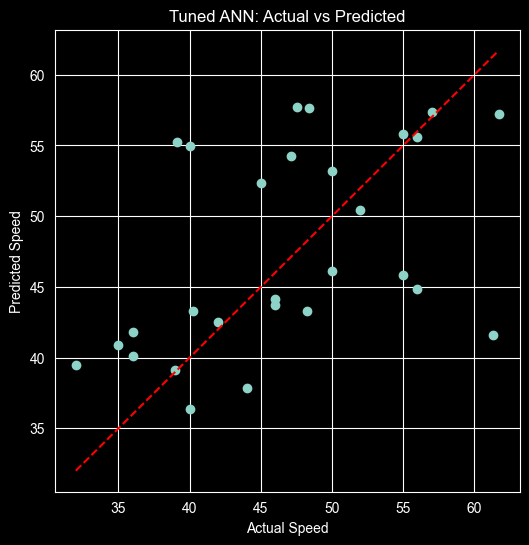

In [240]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_tuned_ann)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("Actual Speed")
plt.ylabel("Predicted Speed")
plt.title("Tuned ANN: Actual vs Predicted")

plt.show()

In [241]:
import pandas as pd

master_table = pd.DataFrame({
    "Model": [
        "MLR",
        "SVR (Base)", "SVR (Tuned)",
        "Random Forest (Base)", "Random Forest (Tuned)",
        "XGBoost (Base)", "XGBoost (Tuned)",
        "ANN (Base)", "ANN (Tuned)"
    ],

    "CV R2": [
        -0.055,
        -0.007, 0.030,
        0.188, 0.260,
        0.033, 0.233,
        -0.078, -0.132
    ],

    "Test R2": [
        0.019,
        0.142, 0.126,
        0.081, 0.264,
        0.022, 0.302,
        0.169, 0.065
    ],

    "CV RMSE": [
        9.615,
        9.734, 9.465,
        8.283, 8.012,
        8.960, 8.264,
        9.852, 10.010
    ],

    "Test RMSE": [
        7.884,
        7.375, 7.443,
        7.633, 6.831,
        7.874, 6.650,
        7.257, 7.700
    ],

    "CV MAE": [
        7.751,
        7.951, 7.626,
        6.408, 6.340,
        7.018, 6.472,
        8.040, 7.923
    ],

    "Test MAE": [
        6.298,
        6.107, 6.254,
        6.179, 5.287,
        5.730, 5.243,
        5.943, 5.914
    ]
})

# Sort by best model (lowest RMSE)
master_table = master_table.sort_values(by="Test RMSE", ascending=True).reset_index(drop=True)

master_table.round(3)

,Model,CV R2,Test R2,CV RMSE,Test RMSE,CV MAE,Test MAE
0,XGBoost (Tuned),0.233,0.302,8.264,6.650,6.472,5.243
1,Random Forest (Tuned),0.260,0.264,8.012,6.831,6.340,5.287
2,ANN (Base),-0.078,0.169,9.852,7.257,8.040,5.943
3,SVR (Base),-0.007,0.142,9.734,7.375,7.951,6.107
4,SVR (Tuned),0.030,0.126,9.465,7.443,7.626,6.254
5,Random Forest (Base),0.188,0.081,8.283,7.633,6.408,6.179
6,ANN (Tuned),-0.132,0.065,10.010,7.700,7.923,5.914
7,XGBoost (Base),0.033,0.022,8.960,7.874,7.018,5.730
8,MLR,-0.055,0.019,9.615,7.884,7.751,6.298


BOOTSTRAPPING FOR BEST TWO MODELS

In [242]:
from sklearn.utils import resample
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

In [243]:
n_iterations = 1000

In [244]:
xgb_r2_scores = []
xgb_rmse_scores = []
xgb_mae_scores = []

for i in range(n_iterations):

    # Bootstrap sample
    X_sample, y_sample = resample(X, y, replace=True, random_state=i)

    # Identify OOB samples
    mask = ~X.index.isin(X_sample.index)
    X_oob = X[mask]
    y_oob = y[mask]

    # Skip if no OOB samples
    if len(X_oob) == 0:
        continue

    # Train
    best_xgb.fit(X_sample, y_sample)

    # Predict on OOB
    y_pred = best_xgb.predict(X_oob)

    # Metrics
    xgb_r2_scores.append(r2_score(y_oob, y_pred))
    xgb_rmse_scores.append(np.sqrt(mean_squared_error(y_oob, y_pred)))
    xgb_mae_scores.append(mean_absolute_error(y_oob, y_pred))

In [245]:
rf_r2_scores = []
rf_rmse_scores = []
rf_mae_scores = []

for i in range(n_iterations):

    X_sample, y_sample = resample(X, y, replace=True, random_state=i)

    mask = ~X.index.isin(X_sample.index)
    X_oob = X[mask]
    y_oob = y[mask]

    if len(X_oob) == 0:
        continue

    best_rf.fit(X_sample, y_sample)

    y_pred = best_rf.predict(X_oob)

    rf_r2_scores.append(r2_score(y_oob, y_pred))
    rf_rmse_scores.append(np.sqrt(mean_squared_error(y_oob, y_pred)))
    rf_mae_scores.append(mean_absolute_error(y_oob, y_pred))

In [246]:
def summarize(scores):
    return np.mean(scores), np.std(scores)

print("XGB R2 Mean & Std:", summarize(xgb_r2_scores))
print("RF R2 Mean & Std:", summarize(rf_r2_scores))

XGB R2 Mean & Std: (np.float64(0.3225437739479015), np.float64(0.1006748761854846))
RF R2 Mean & Std: (np.float64(0.3090551538007541), np.float64(0.10647471845151243))


In [247]:
def confidence_interval(scores):
    return np.percentile(scores, 2.5), np.percentile(scores, 97.5)

print("XGB R2 95% CI:", confidence_interval(xgb_r2_scores))
print("RF R2 95% CI:", confidence_interval(rf_r2_scores))

XGB R2 95% CI: (np.float64(0.08887925111286625), np.float64(0.4940304214462928))
RF R2 95% CI: (np.float64(0.07638540374280595), np.float64(0.48430331834119694))


In [248]:
bootstrap_results = pd.DataFrame({
    "Model": ["XGBoost Tuned", "Random Forest Tuned"],

    "Mean R2": [
        np.mean(xgb_r2_scores),
        np.mean(rf_r2_scores)
    ],

    "Std R2": [
        np.std(xgb_r2_scores),
        np.std(rf_r2_scores)
    ],

    "R2 Lower (2.5%)": [
        np.percentile(xgb_r2_scores, 2.5),
        np.percentile(rf_r2_scores, 2.5)
    ],

    "R2 Upper (97.5%)": [
        np.percentile(xgb_r2_scores, 97.5),
        np.percentile(rf_r2_scores, 97.5)
    ],

    "Mean RMSE": [
        np.mean(xgb_rmse_scores),
        np.mean(rf_rmse_scores)
    ],

    "Std RMSE": [
        np.std(xgb_rmse_scores),
        np.std(rf_rmse_scores)
    ]
})

bootstrap_results.round(3)

,Model,Mean R2,Std R2,R2 Lower (2.5%),R2 Upper (97.5%),Mean RMSE,Std RMSE
0,XGBoost Tuned,0.323,0.101,0.089,0.494,8.383,0.737
1,Random Forest Tuned,0.309,0.106,0.076,0.484,8.462,0.741


In [249]:
np.percentile(xgb_rmse_scores, 2.5), np.percentile(xgb_rmse_scores, 97.5)

(np.float64(7.014176068123435), np.float64(9.909498305125712))

In [250]:
np.percentile(xgb_mae_scores, 2.5), np.percentile(xgb_mae_scores, 97.5)

(np.float64(5.472280579782882), np.float64(7.87112458753443))

In [251]:
bootstrap_results_updated = pd.DataFrame({
    "Model": ["XGBoost Tuned", "Random Forest Tuned"],

    # R2
    "Mean R2": [
        np.mean(xgb_r2_scores),
        np.mean(rf_r2_scores)
    ],
    "R2 Lower (2.5%)": [
        np.percentile(xgb_r2_scores, 2.5),
        np.percentile(rf_r2_scores, 2.5)
    ],
    "R2 Upper (97.5%)": [
        np.percentile(xgb_r2_scores, 97.5),
        np.percentile(rf_r2_scores, 97.5)
    ],

    # RMSE
    "Mean RMSE": [
        np.mean(xgb_rmse_scores),
        np.mean(rf_rmse_scores)
    ],
    "RMSE Lower (2.5%)": [
        np.percentile(xgb_rmse_scores, 2.5),
        np.percentile(rf_rmse_scores, 2.5)
    ],
    "RMSE Upper (97.5%)": [
        np.percentile(xgb_rmse_scores, 97.5),
        np.percentile(rf_rmse_scores, 97.5)
    ],

    # MAE
    "Mean MAE": [
        np.mean(xgb_mae_scores),
        np.mean(rf_mae_scores)
    ],
    "MAE Lower (2.5%)": [
        np.percentile(xgb_mae_scores, 2.5),
        np.percentile(rf_mae_scores, 2.5)
    ],
    "MAE Upper (97.5%)": [
        np.percentile(xgb_mae_scores, 97.5),
        np.percentile(rf_mae_scores, 97.5)
    ]
})

bootstrap_results_updated.round(3)

,Model,Mean R2,R2 Lower (2.5%),R2 Upper (97.5%),Mean RMSE,RMSE Lower (2.5%),RMSE Upper (97.5%),Mean MAE,MAE Lower (2.5%),MAE Upper (97.5%)
0,XGBoost Tuned,0.323,0.089,0.494,8.383,7.014,9.909,6.567,5.472,7.871
1,Random Forest Tuned,0.309,0.076,0.484,8.462,7.036,9.951,6.660,5.531,7.947
